In [158]:
import pandas as pd

In [173]:
mesa_data = pd.read_csv("2025-03-19-mesa-de-sol-microgrid-data/Apr_2023.csv")

In [174]:
mesa_data.columns

Index(['Timestamp', 'Battery_Active_Power',
       'Battery_Active_Power_Set_Response', 'PVPCS_Active_Power',
       'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency',
       'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'],
      dtype='object')

In [334]:
mesa_df.head()

,Timestamp,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,MG-LV-MSB_AC_Voltage,Receiving_Point_AC_Voltage,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,Inlet_Temperature_of_Chilled_Water,Outlet_Temperature
0,2022-08-01 00:00:01,0.0,0.0,0.0,0.0,-1.0,110.0,40.0,37.0,40.0,-27.0,485.0,485.0,485.0,59.980000,59.980000,19.9,16.1
1,2022-08-01 00:00:11,0.0,0.0,0.0,0.0,-1.0,110.0,40.0,37.0,40.0,-28.0,485.0,485.0,485.0,59.980000,59.980000,20.0,16.1
2,2022-08-01 00:00:21,0.0,0.0,0.0,0.0,-1.0,110.0,40.0,37.0,40.0,-28.0,485.0,485.0,485.0,59.970001,59.970001,20.0,16.1
3,2022-08-01 00:00:31,0.0,0.0,0.0,0.0,-1.0,110.0,40.0,37.0,40.0,-28.0,485.0,485.0,485.0,59.970001,59.970001,20.0,16.1
4,2022-08-01 00:00:41,0.0,0.0,0.0,0.0,-1.0,110.0,40.0,37.0,40.0,-28.0,485.0,485.0,485.0,59.980000,59.980000,20.0,16.1


In [179]:
price_data = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv", skiprows=0)

In [180]:
price_data.columns

Index(['Date', 'Hour', 'HOEP', 'Hour 1 Predispatch', 'Hour 2 Predispatch',
       'Hour 3 Predispatch', 'OR 10 Min Sync', 'OR 10 Min non-sync',
       'OR 30 Min'],
      dtype='object')

In [181]:
price_data.head()

,Date,Hour,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min
0,2024-01-01,1,46.42,34.68,33.80,27.83,1.26,0.17,0.17
1,2024-01-01,2,35.85,33.73,32.13,33.80,0.98,0.15,0.15
2,2024-01-01,3,27.73,33.73,27.22,29.86,0.98,0.15,0.15
3,2024-01-01,4,19.34,27.35,27.26,27.34,0.15,0.11,0.10
4,2024-01-01,5,20.23,27.20,27.26,27.27,0.10,0.10,0.10


In [182]:
wind_data = pd.read_csv("2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")

In [335]:
wind_df.columns

Index(['Time', 'WindSpeed', 'Power'], dtype='object')

In [336]:
wind_df.head()

,Time,WindSpeed,Power
0,2014-10-07 01:20:00,8.22,40.526173
1,2014-10-07 01:30:00,8.09,38.552540
2,2014-10-07 01:50:00,7.21,21.313683
3,2014-10-07 02:00:00,6.75,18.031418
4,2014-10-07 02:10:00,6.52,16.593281


In [299]:
len(mesa_data)

267624

In [337]:
# Testing function outside of class
def preprocess_data(mesa_data, price_data, wind_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Process mesa data
    # Create a matching key for mesa data: 'MM-DD HH:MM' - THIS IS THE KEY THING DONE FOR making sure everything makes sense
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    # print(mesa_unique.head(2))
    # print(mesa_unique.tail(2))
    
    # Resample price data to 5min and create matching key
    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    # print(price_unique.head(2))
    # print(price_unique.tail(2))

    # Process wind data
    # Resample wind data to 5min and create matching key
    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    # print(wind_unique.head(2))
    # print(wind_unique.tail(2))

    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    return merged_data

In [338]:
aligned_data = preprocess_data(mesa_df, price_data, wind_data)

In [339]:
aligned_data.head(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Outlet_Temperature,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,WindSpeed,Power
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-05-01 00:00:00,0.0,0.0,0.0,0.0,-1.0,180.0,40.0,38.0,40.0,-13.966667,...,22.156667,21.99,27.01,27.02,26.61,0.16,0.15,0.11,5.49,10.237898
2022-05-01 00:05:00,0.0,0.0,0.0,0.0,-1.0,180.0,40.0,38.0,40.0,-15.033333,...,22.130000,21.99,27.01,27.02,26.61,0.16,0.15,0.11,5.50,9.903779
2022-05-01 00:10:00,0.0,0.0,0.0,0.0,-1.0,180.0,40.0,38.0,40.0,-15.000000,...,22.156667,21.99,27.01,27.02,26.61,0.16,0.15,0.11,5.51,9.569660


In [340]:
aligned_data.tail(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Outlet_Temperature,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,WindSpeed,Power
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-04-30 23:45:00,-0.103333,0.0,0.0,0.0,-0.743333,200.0,40.0,38.0,40.0,-13.533333,...,14.803333,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.845,13.182160
2023-04-30 23:50:00,-0.073333,0.0,0.0,0.0,-0.790000,200.0,40.0,38.0,40.0,-13.133333,...,14.803333,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.620,12.052889
2023-04-30 23:55:00,-0.120000,0.0,0.0,0.0,-0.826667,200.0,40.0,38.0,40.0,-13.166667,...,14.800000,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.555,11.145394


In [311]:
aligned_data.columns

Index(['Battery_Active_Power', 'Battery_Active_Power_Set_Response',
       'PVPCS_Active_Power', 'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency',
       'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature', 'HOEP',
       'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
       'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min', 'WindSpeed',
       'Power'],
      dtype='object')

In [312]:
aligned_data.tail(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Outlet_Temperature,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,WindSpeed,Power
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-04-30 23:45:00,-0.103333,0.0,0.0,0.0,-0.743333,200.0,40.0,38.0,40.0,-13.533333,...,14.803333,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.845,13.182160
2023-04-30 23:50:00,-0.073333,0.0,0.0,0.0,-0.790000,200.0,40.0,38.0,40.0,-13.133333,...,14.803333,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.620,12.052889
2023-04-30 23:55:00,-0.120000,0.0,0.0,0.0,-0.826667,200.0,40.0,38.0,40.0,-13.166667,...,14.800000,21.38,25.56,25.56,25.56,0.31,0.17,0.14,5.555,11.145394


In [313]:
len(aligned_data)

105120

/var/folders/qd/1pjv967d1ylfl4mzr8flbvb00000gn/T/ipykernel_80096/1149740880.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = aligned_data.resample('1H').mean()


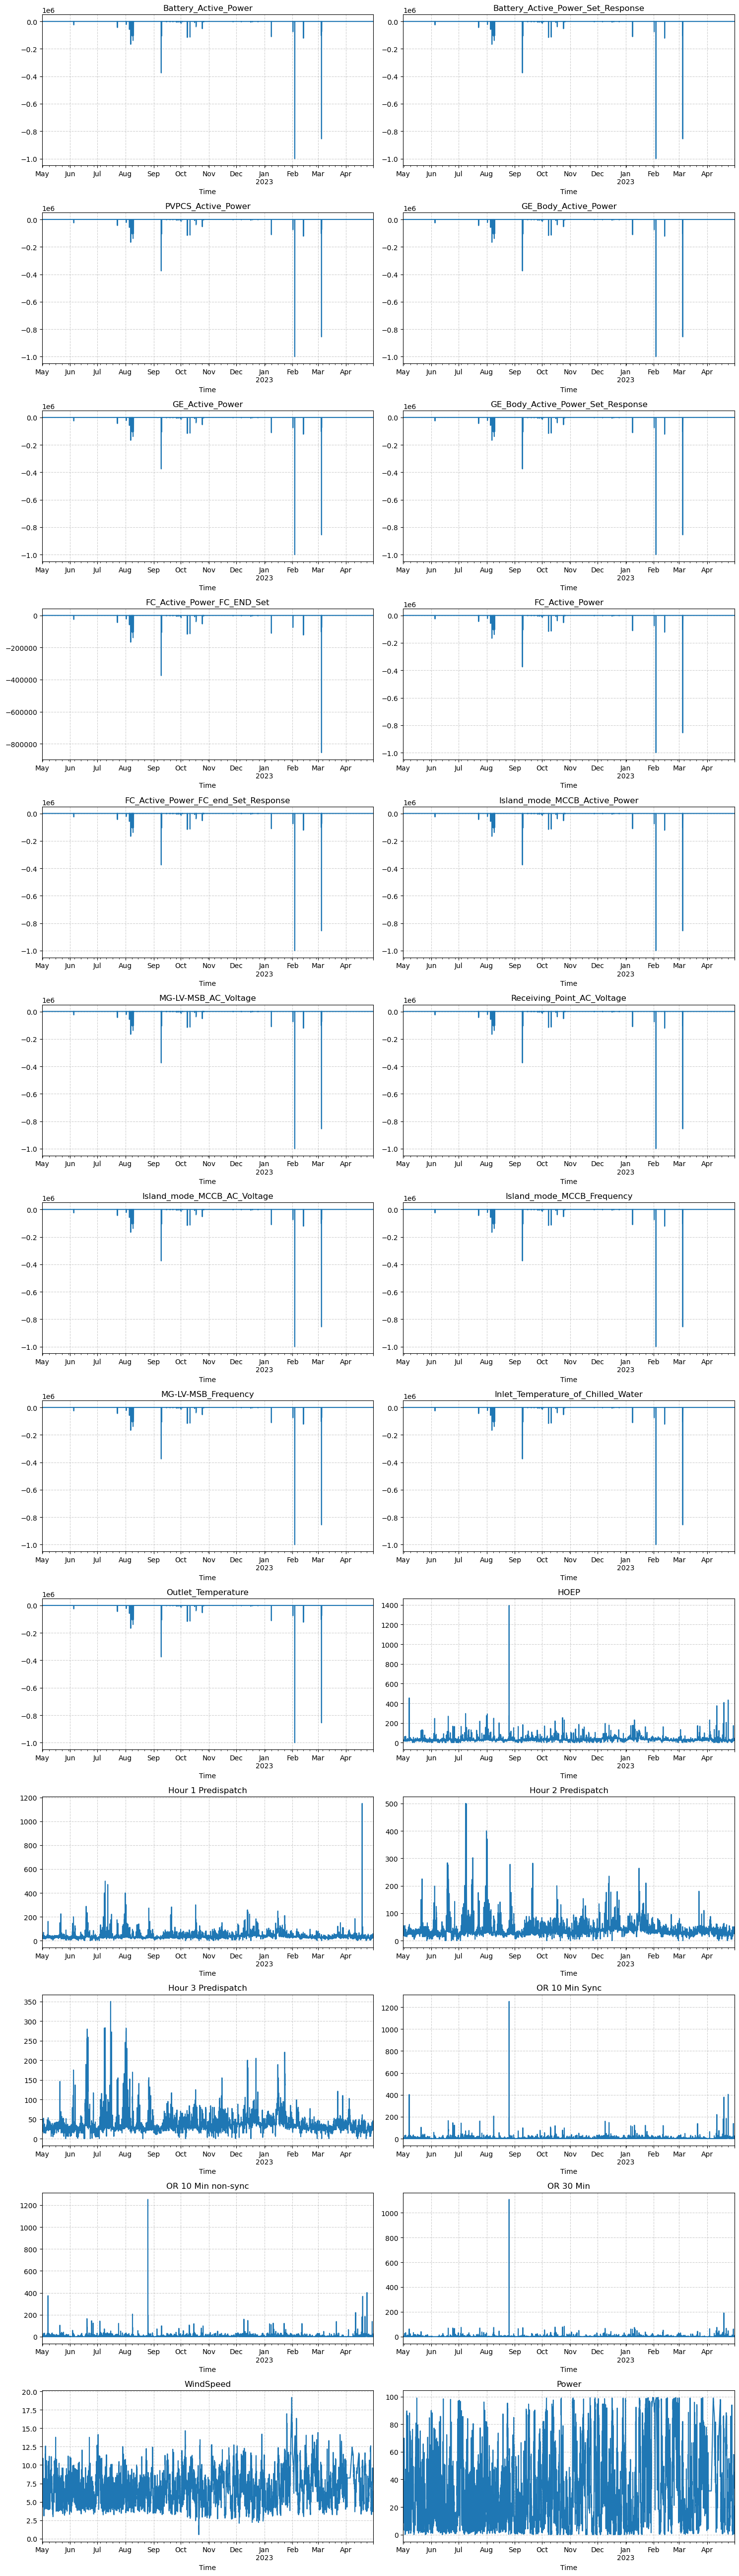

In [342]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_hourly_variables(aligned_data):
    # Resample to hourly granularity
    hourly_data = aligned_data.resample('1H').mean()
    # Get all columns to plot
    columns = hourly_data.columns
    # Create a figure with subplots - calculate rows needed
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()  # Flatten to easily iterate
    # Plot each variable
    for i, col in enumerate(columns):
        ax = axes[i]
        hourly_data[col].plot(ax=ax, title=col)
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)
    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_hourly_variables(aligned_data)

In [348]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import math
from stable_baselines3 import PPO
import torch
from datetime import datetime, timedelta

In [391]:
class MicrogridEnv(gym.Env):
    """
    A microgrid environment for reinforcement learning with PPO.
    This environment simulates a microgrid with:
    - Solar PV generation
    - Wind generation
    - 160 kWh Lead Acid Battery Storage
    - Fuel generator engine
    - Fuel cell
    - Grid connection
    - Critical, essential, and non-critical loads
    - DC/AC inverters for power conversion
    """

    # Need to check for accuracy of these constants * * *
    def __init__(self, mesa_data, price_data, wind_data, episode_length=288):  # 288 = 24 hours at 5-min intervals (1440 / 5 = 288)
        super(MicrogridEnv, self).__init__()
        
        # Preprocess and align all data to 5-minute intervals
        self.data = self._preprocess_data(mesa_data, price_data, wind_data)
        
        # Battery parameters
        self.battery_capacity = 160.0  # kWh
        self.min_battery_soc = 0.2  # Minimum allowable state of charge
        self.max_battery_charge_rate = 30.0  # kW
        self.max_battery_discharge_rate = 30.0  # kW
        self.battery_charging_efficiency = 0.85
        self.battery_discharging_efficiency = 0.9
        
        # Inverter efficiencies
        self.dc_ac_inverter_efficiency = 0.95
        
        # Component power ratings
        self.max_pv_power = 100.0  # kW
        self.max_wind_power = 50.0  # kW
        self.max_generator_power = 125.0  # kW
        self.min_generator_power = 20.0  # kW for stable operation
        self.max_fuel_cell_power = 40.0  # kW
        self.min_fuel_cell_power = 5.0  # kW for stable operation
        
        # Load estimates (can be refined with actual data)
        self.base_critical_load = 30.0  # kW
        self.base_essential_load = 40.0  # kW
        self.base_non_critical_load = 50.0  # kW
        
        # Initial state
        self.battery_soc = 0.5  # Start at 50% capacity
        self.current_step = 0
        self.episode_length = episode_length
        self.start_idx = 0
        
        # Define action and observation spaces
        self.action_space = spaces.Box(
            low=np.array([-1.0, 0.0, 0.0, 0.0, 0.0]),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # Observation space: features describing the current state of the microgrid
        # 24 features in our state space
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(24,),  
            dtype=np.float32
        )
    
    # Preprocess and align all datasets to 5-minute intervals (ignores year)
    def _preprocess_data(self, mesa_data, price_data, wind_data):
        # Process mesa data
        # Create a matching key for mesa data: 'MM-DD HH:MM' - THIS IS THE KEY THING DONE FOR making sure everything makes sense
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
        # print(mesa_unique.head(2))
        # print(mesa_unique.tail(2))
        
        # Resample price data to 5min and create matching key
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
        # print(price_unique.head(2))
        # print(price_unique.tail(2))
    
        # Process wind data
        # Resample wind data to 5min and create matching key
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        # print(wind_unique.head(2))
        # print(wind_unique.tail(2))
    
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        return merged_data

    
    # This function is called at the start of every episode - we start at a fixed battery percentage, and start index
    def reset(self, seed=None, options=None):
        """
        Reset the environment to begin a new episode.
        
        Parameters:
        -----------
        seed : int, optional
            Random seed for reproducibility
        options : dict, optional
            Additional options for reset
            
        Returns:
        --------
        observation : array
            Initial observation
        info : dict
            Additional information
        """
        # Set seed if provided
        if seed is not None:
            np.random.seed(seed)
        
        # Reset battery state
        self.battery_soc = 0.5  # Start at 50% capacity
        
        # Choose a random starting point in the data
        max_start_idx = len(self.data) - self.episode_length - 1
        self.start_idx = np.random.randint(0, max_start_idx) if max_start_idx > 0 else 0
        self.current_step = 0
        
        # Return observation and info
        return self._get_observation(), {}

    # Because reset for every epsisode starts at a random idx, we need to use this idx convention
    def _get_observation(self):
        # Current index
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        
        # Time features
        timestamp = self.data.index[idx]
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0  # Normalize to [0,1]
        month_of_year = (timestamp.month - 1) / 11.0  # Normalize to [0,1]
        
        # Power system state
        battery_power = current_data.get('Battery_Active_Power', 0) / self.data['Island_mode_MCCB_Active_Power'].max()
        pv_power = current_data.get('PVPCS_Active_Power', 0) / self.data['Island_mode_MCCB_Active_Power'].max()
        generator_power = current_data.get('GE_Active_Power', 0) / self.data['Island_mode_MCCB_Active_Power'].max()
        fuel_cell_power = current_data.get('FC_Active_Power', 0) / self.data['Island_mode_MCCB_Active_Power'].max()
        grid_power = current_data.get('Island_mode_MCCB_Active_Power', 0) / self.data['Island_mode_MCCB_Active_Power'].max()
        
        # Grid measurements
        grid_voltage = current_data.get('MG-LV-MSB_AC_Voltage', 480) / self.data['MG-LV-MSB_AC_Voltage'].max()  # Normalize by max expected voltage
        grid_frequency = current_data.get('MG-LV-MSB_Frequency', 60) / self.data['MG-LV-MSB_Frequency'].max()  # Normalize by max expected frequency
        
        # Energy price and forecasts
        current_price = current_data.get('HOEP', 30) / self.data['HOEP'].max()  # Normalize by expected max price
        price_forecast_1h = current_data.get('Hour 1 Predispatch', 30) / self.data['Hour 1 Predispatch'].max()
        price_forecast_2h = current_data.get('Hour 2 Predispatch', 30) / self.data['Hour 2 Predispatch'].max()
        price_forecast_3h = current_data.get('Hour 3 Predispatch', 30) / self.data['Hour 3 Predispatch'].max()
        
        # Wind data
        wind_speed = current_data.get('WindSpeed', 5) / current_data['WindSpeed'].max()  # Normalize by expected max
        wind_power = current_data.get('Power', 20) / self.max_wind_power
        
        # Temperature data
        # Should take out this state variable!
        inlet_temp = current_data.get('Inlet_Temperature_of_Chilled_Water', 15) / 30.0
        outlet_temp = current_data.get('Outlet_Temperature', 15) / 30.0
        
        # Estimated loads based on power balance
        # In a real implementation, these would be more accurately modeled
        # Getting the ratios of total max_pv_power multiplied by the max to get the current power
        total_generation = (pv_power * self.max_pv_power + 
                           wind_power * self.max_wind_power + 
                           generator_power * self.max_generator_power + 
                           fuel_cell_power * self.max_fuel_cell_power)
        # If grid_power is negative, we are gaining power, if it is positive, we are losing power
        total_load = total_generation - battery_power * self.max_battery_discharge_rate - grid_power * 200.0
        total_load = max(0, total_load)
        
        # Normalize loads
        total_load_normalized = total_load / (self.base_critical_load + self.base_essential_load + self.base_non_critical_load)
        
        # Create the observation vector
        observation = np.array([
            sin_hour,
            cos_hour,
            day_of_week,
            month_of_year,
            self.battery_soc, # Current battery charge percentage
            battery_power,
            pv_power,
            wind_power,
            generator_power,
            fuel_cell_power,
            grid_power,
            grid_voltage,
            grid_frequency,
            current_price,
            price_forecast_1h,
            price_forecast_2h,
            price_forecast_3h,
            wind_speed,
            inlet_temp,
            outlet_temp,
            total_load_normalized,
            max(0, -grid_power),  # Grid export (negative grid_power means exporting)
            max(0, grid_power),   # Grid import (positive grid_power means importing)
            (self.episode_length - self.current_step) / self.episode_length  # Time remaining in episode
        ], dtype=np.float32)
        return observation
    
    def step(self, action):
        """
        Take a step in the environment with the given action.
        Actions:
        [0]: Battery power (-1 to 1, where -1 = max discharge, 1 = max charge)
        [1]: Fuel cell power (0 to 1, where 0 = off, 1 = max power)
        [2]: Generator power (0 to 1, where 0 = off, 1 = max power)
        [3]: Non-critical load shedding (0 to 1, where 0 = no shedding, 1 = full shedding)
        [4]: Island mode decision (0 to 1, where < 0.5 = grid-connected, >= 0.5 = island mode)
        """
        # Get current data
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        
        # - - - - Action processing - - - -
        # Battery action (scaled from -1 to 1)
        battery_power_setpoint = action[0] * self.max_battery_discharge_rate
        
        # Fuel cell action (scaled from 0 to 1)
        fuel_cell_setpoint = action[1] * self.max_fuel_cell_power
        if fuel_cell_setpoint < self.min_fuel_cell_power:
            fuel_cell_setpoint = 0  # Below minimum stable output, turn off
        
        # Generator action (scaled from 0 to 1)
        generator_setpoint = action[2] * self.max_generator_power
        if generator_setpoint < self.min_generator_power:
            generator_setpoint = 0  # Below minimum stable output, turn off
        
        # Load shedding decision (scaled from 0 to 1)
        load_shedding = action[3]
        
        # Island mode decision (binary)
        island_mode = action[4] >= 0.5
        
        # ====== Environment dynamics ======
        
        # Available renewable power
        solar_power = current_data.get('PVPCS_Active_Power', 0)
        
        # Scale wind power to appropriate capacity
        wind_data_power = current_data.get('Power', 0)

        # Random constant currently chosen here for now, need to check if its valid or not
        wind_scaling_factor = self.max_wind_power / 50.0  # Assuming data is for a 50kW turbine
        wind_power = wind_data_power * wind_scaling_factor
        
        # Battery dynamics
        # Limit charge/discharge based on SoC
        max_discharge_power = min(self.max_battery_discharge_rate, 
                               self.battery_soc * self.battery_capacity * 12 * self.battery_discharging_efficiency)  # 12 = full discharge in 5 minutes
        max_charge_power = min(self.max_battery_charge_rate, 
                            (1 - self.battery_soc) * self.battery_capacity * 12 / self.battery_charging_efficiency)  # 12 = full charge in 5 minutes
        
        # Apply battery power limits
        if battery_power_setpoint < 0:  # Discharging
            actual_battery_power = max(battery_power_setpoint, -max_discharge_power)
        else:  # Charging
            actual_battery_power = min(battery_power_setpoint, max_charge_power)
        
        # Calculate energy change (kWh) over 5 minutes
        if actual_battery_power < 0:  # Discharging
            energy_change = actual_battery_power * self.battery_discharging_efficiency * (5/60)
        else:  # Charging
            energy_change = actual_battery_power / self.battery_charging_efficiency * (5/60)
        
        # Update battery SoC
        new_battery_soc = self.battery_soc - energy_change / self.battery_capacity
        new_battery_soc = max(0, min(1, new_battery_soc))  # Ensure SoC within [0, 1]
        
        # Apply inverter efficiency to DC sources
        solar_power_ac = solar_power * self.dc_ac_inverter_efficiency
        wind_power_ac = wind_power * self.dc_ac_inverter_efficiency
        battery_power_ac = -actual_battery_power * self.dc_ac_inverter_efficiency if actual_battery_power < 0 else 0
        
        # Calculate total AC generation
        total_generation_ac = solar_power_ac + wind_power_ac + battery_power_ac + generator_setpoint + fuel_cell_setpoint
        
        # Calculate loads
        # In a real implementation, these would be more detailed and perhaps time-varying
        critical_load = self.base_critical_load
        essential_load = self.base_essential_load
        non_critical_load = self.base_non_critical_load * (1 - load_shedding)
        
        total_load = critical_load + essential_load + non_critical_load
        
        # Grid interaction
        if island_mode:
            # In island mode, no grid exchange
            grid_power = 0
            
            # Check if generation meets load
            if total_generation_ac < critical_load + essential_load:
                # Critical situation: can't meet critical and essential loads
                unmet_critical_load = (critical_load + essential_load) - total_generation_ac
                unmet_critical_load = max(0, unmet_critical_load)
                unmet_non_critical_load = 0
                
                # Apply severe penalty for unmet critical load
                load_penalty = unmet_critical_load * 100
            elif total_generation_ac < total_load:
                # Can meet critical and essential, but not all non-critical
                unmet_critical_load = 0
                unmet_non_critical_load = total_load - total_generation_ac
                
                # Apply moderate penalty for unmet non-critical load
                load_penalty = unmet_non_critical_load * 10
            else:
                # All loads met
                unmet_critical_load = 0
                unmet_non_critical_load = 0
                load_penalty = 0
                
            # Excess generation in island mode is wasted
            excess_generation = max(0, total_generation_ac - total_load)
        else:
            # Grid connected - grid provides the balance
            grid_power = total_load - total_generation_ac
            
            # No unmet loads in grid-connected mode (grid supplies the difference)
            unmet_critical_load = 0
            unmet_non_critical_load = 0
            load_penalty = 0
            excess_generation = 0
        
        # - - - -  Reward calculation - - - -
        
        # Get current energy price
        energy_price = current_data.get('HOEP', 30)  # Default to 30 if not available
        
        # Reward for renewable usage
        renewable_reward = (solar_power_ac + wind_power_ac) * 0.2
        
        # Grid costs/revenue
        if grid_power > 0:  # Importing from grid
            grid_cost = grid_power * energy_price * 0.01
            grid_revenue = 0
        else:  # Exporting to grid
            grid_cost = 0
            grid_revenue = -grid_power * energy_price * 0.007  # Slightly less than purchase price
        
        # Fuel costs
        generator_fuel_cost = generator_setpoint * 0.15  # Higher cost for generator
        fuel_cell_cost = fuel_cell_setpoint * 0.10  # Lower cost for fuel cell
        
        # Battery health penalty
        if new_battery_soc < self.min_battery_soc:
            battery_health_penalty = (self.min_battery_soc - new_battery_soc) * 200  # Severe penalty for going below minimum SoC
        else:
            battery_health_penalty = 0
        
        # Stability bonus (avoid rapid changes in setpoints)
        stability_bonus = 0
        
        # Total reward
        reward = (renewable_reward + grid_revenue - grid_cost - generator_fuel_cost - 
                 fuel_cell_cost - battery_health_penalty - load_penalty + stability_bonus) / 100 # Scaling down rewards
        
        # Update state
        self.battery_soc = new_battery_soc
        self.current_step += 1
        
        # Check if episode is done
        done = self.current_step >= self.episode_length
        
        # Additional info
        info = {
            'battery_soc': self.battery_soc,
            'solar_power': solar_power,
            'wind_power': wind_power,
            'generator_power': generator_setpoint,
            'fuel_cell_power': fuel_cell_setpoint,
            'grid_power': grid_power,
            'unmet_critical_load': unmet_critical_load,
            'unmet_non_critical_load': unmet_non_critical_load,
            'renewable_usage': (solar_power_ac + wind_power_ac) / max(1e-5, total_load),
            'grid_dependency': max(0, grid_power) / max(1e-5, total_load)
        }
        
        return self._get_observation(), reward, done, False, info

In [392]:
# PPO Training Setup
def train_ppo_agent(env, total_timesteps=1000000):
    """Train a PPO agent for the microgrid environment."""
    
    # Define policy network architecture
    policy_kwargs = dict(
        net_arch=dict(pi=[256, 128, 64], vf=[256, 128, 64]),
        activation_fn=torch.nn.ReLU
    )
    
    # Create PPO agent
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        clip_range_vf=0.2,
        normalize_advantage=True,
        ent_coef=0.01,
        policy_kwargs=policy_kwargs,
        verbose=1
    )
    
    # Train the agent
    model.learn(total_timesteps=total_timesteps)
    
    return model

In [393]:
import glob
import os

def read_and_merge_csvs(folder_path):
    # Find all CSV files in the folder
    all_csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    # Read all CSVs into a list of DataFrames
    df_list = [pd.read_csv(file) for file in all_csv_files]

    # Merge all DataFrames (concatenating them)
    merged_df = pd.concat(df_list, ignore_index=True)

    return merged_df

In [394]:
len(mesa_df)

3929794

In [395]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*precision lowered by casting to float32.*")

In [388]:
mesa_df = read_and_merge_csvs("2025-03-19-mesa-de-sol-microgrid-data")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv")
wind_df = pd.read_csv("2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")

In [396]:
# Create environment
env = MicrogridEnv(mesa_df, price_df, wind_df)

In [ ]:
# Train PPO agent
model = train_ppo_agent(env, total_timesteps=500000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 288      |
|    ep_rew_mean     | -950     |
| time/              |          |
|    fps             | 268      |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 288         |
|    ep_rew_mean          | -940        |
| time/                   |             |
|    fps                  | 268         |
|    iterations           | 2           |
|    time_elapsed         | 15          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008648548 |
|    clip_fraction        | 0.0731      |
|    clip_range           | 0.2         |
|    clip_range_vf  

In [333]:
# Save the trained model
model.save("microgrid_ppo_model")

NameError: name 'model' is not defined

In [332]:
# Test the model
obs = env.reset()
for i in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    if done:
        obs = env.reset()

NameError: name 'model' is not defined